# Lab 7

In [146]:
### MATPLOTLIB SETUP ###
import math
from math import sqrt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from scipy.optimize import curve_fit
import sys
pd.set_option('display.float_format', lambda x: '%e' % x)

## Amit's library with some utility functions for reading and processing scope data; reproduced below
sys.path.append("../../")
from lib import *

from rich.console import Console
from rich.syntax import Syntax
Console().print(Syntax.from_path("../../lib.py", line_numbers=True, theme="monokai"))

## Jupyter magic
%matplotlib
%matplotlib ipympl
%load_ext autoreload
%autoreload 2

    1 import csv                                                                                                   
    2 import pandas as pd                                                                                          
    3 import numpy as np                                                                                           
    4 from scipy.signal import find_peaks                                                                          
    5                                                                                                              
    6 R = 5 # Load Resistance                                                                                      
    7 VG = 18 # Input Voltage                                                                                      
    8 Fs = 50500 # Measured frequency                                                                              
    9 Ts = 1/ Fs                                                                                                   
   10 R_SHUNT = 0.05 # from schematic                                                                              
   11                                                                                                              
   12 # read funky Rigol CSV format                                                                                
   13 def read_rigol_csv(csv_file_name):                                                                           
   14     with open(csv_file_name) as f:                                                                           
   15         rows = list(csv.reader(f))                                                                           
   16         i = 0                                                                                                
   17         while rows[0][i] != "":                                                                              
   18             i = i+1                                                                                          
   19         numcols = i-2                                                                                        
   20         t0 = float(rows[1][numcols])                                                                         
   21         dT = float(rows[1][numcols+1])                                                                       
   22                                                                                                              
   23     data = pd.read_csv(csv_file_name, usecols=range(0,numcols), skiprows=[1])                                
   24     data['X'] = t0+data['X']*dT                                                                              
   25     return data, t0, dT                                                                                      
   26                                                                                                              
   27 def import_and_clean(name, cols, filt, filt_len=10):                                                         
   28     """                                                                                                      
   29     Import and clean some data from the Rigol scope                                                          
   30                                                                                                              
   31     @param name: name of csv file (assumed to live in `./data`)                                              
   32     @param cols: what to rename columns to                                                                   
   33     @param filt: whether to

Using matplotlib backend: ipympl
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Prelab

### Measuring Parasitic Capacitance

The first step is adding a parallel capacitance to measure the parasitic capacitance in our converter. The resonant frequency of our circuit (an LC circuit) is

$$
f_1 = \frac{1}{2\pi\sqrt{L C_x}}
$$

When we add our additional parallel capacitance, this becomes

$$
f_2 = \frac{1}{2\pi\sqrt{L \cdot (C_x + C_2)}}
$$

Where $C_x$ is the parasitic capacitance and $C_2$ is our known additional capactiance (selection of this value will be covered shortly). We can manipulate these equations to find $C_x$ by rearranging them to solve for L.

$$
L = \frac{1}{(2\pi f_1)^2 C_x}, L = \frac{1}{(2\pi f_2)^2 \cdot (C_x+C_2)}
$$

We can set these equations equal to each other, and solve for $C_x$

$$
C_x = \frac{f_2^2 \cdot C_2}{f_1^2 - f_2^2}
$$

To select the value of $C_2$, I looked at the datasheet for the FDP61N20 FET to find its output capactiance (typical value 645 pF), and selected a capacitor value near that from the menu (680 pF) - enough to cause a measurable difference in the frequency but not so much so as to significantly affect our system's behavior.

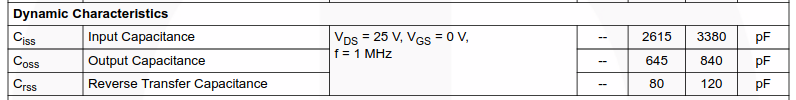

The below code cell performs the calculations above, using data collected from lab 6 as well as a new measurement with our parallel capacitor

lf Frequency with added 680 pF capacitance: 6_820_567 | HF Frequency with just parasitic capacitance (from lab 6): 10_221_465


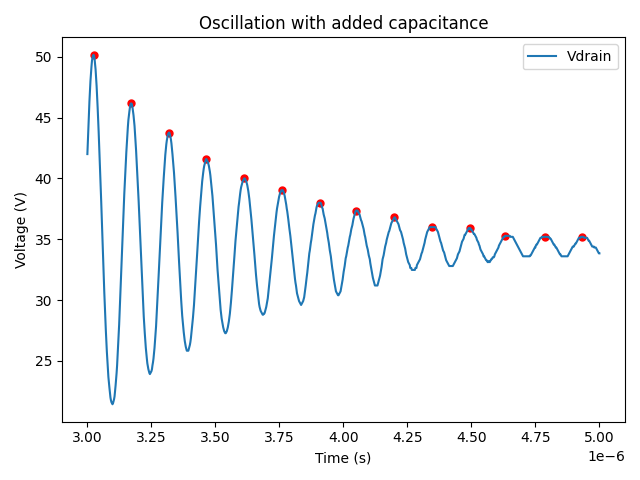

In [147]:
c_added, dt = import_and_clean("c_added", ["Vshunt", "Vdrain"], True)
cx_f = 10_221_465

c_added_time = c_added[(c_added['X'] > 3e-6) & (c_added['X'] < 5e-6)]
c_added_peaks, c_added_f = frequency(c_added_time["Vdrain"], dt, 0.8, 10)

plt.clf()
fig, ax1 = plt.subplots()
c_added_time.plot(x='X', y='Vdrain', ax=ax1, title="Oscillation with added capacitance")
c_added_time.iloc[c_added_peaks].plot(x='X', y='Vdrain', kind='scatter', ax=ax1, s=25, c='red')
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Voltage (V)")
fig.tight_layout()
print(f'lf Frequency with added 680 pF capacitance: {round(c_added_f):_} |', f'HF Frequency with just parasitic capacitance (from lab 6): {cx_f:_}')

In [148]:
C_2 = 680e-12

# Calculate parasitic capacitance C_p
Cx = (c_added_f**2 * C_2) / (cx_f**2 - c_added_f**2)
print(f"Parasitic capacitance: {round(Cx * 1e12, 2)} pF")

Parasitic capacitance: 545.8 pF


### Selecting Snubber Components

Taking our parasitic capacitance previously calculated, as well as a magnetizing inductance of 18.49 uH (from Lab 6) a desired $\zeta$ of 0.7, and 
We start by calculating our snubber capacitance as 3 times our parasitic capacitance:

In [149]:
C_snub = 3*Cx
print(f"Snubber capacitance: {round(C_snub * 1e12, 2)} pF")

Snubber capacitance: 1637.4 pF


To find our snubber resistance, we can use the equation

$$
R = 2 \zeta \sqrt{\frac{L}{C}}
$$

However, to apply it, we need both our magnetizing and leakage inductances. We know our magnetizing inductance from lab 6, but we need to find our leakage inductances.

Looking at the other equation for an LC circuit, we know

$$
w_0 = \frac{1}{\sqrt{LC}}
$$

Using our high frequency example (where the main inductance in the circuit is just the leakage inductance, and the capacitance is the parasitic capacitnace), we can rearrange as

$$
L = \frac{1}{C_x \cdot \omega}
$$

Taking this value as the total leakage inductance, we will assume both sides of the leakage inductance are relatively symmetric and approximate them as equal


In [150]:
w = cx_f * 2 * np.pi
Lsigma_tot = 1/(Cx * w**2)
Lsigma = Lsigma_tot/2
print(f"Total Leakage Inductance {round(Lsigma_tot * 1e6, 3)} uH")
print(f"Leakage Inductance per side {round(Lsigma * 1e6, 3)} uH")

Total Leakage Inductance 0.444 uH
Leakage Inductance per side 0.222 uH


Back to the snubber! Taking our desired $\zeta$ as 0.7, we now plug into the equation from earlier to find our resistances as follows.

Note that we use both sides of the leakage inductance for the high frequency, since that's the path of least inductance, but for the low frequency ring, the second leakage inductance is not in the picture, so the only path is through the magnetizing inductance.

In [151]:
zeta = 0.7
Lm = 18.49 * 1e-6
R_snub_hf = 2 * zeta * np.sqrt(Lsigma_tot/C_snub)
R_snub_lf = 2 * zeta * np.sqrt((Lsigma + Lm)/C_snub)

print(f"HF snubber resistance: {round(R_snub_hf, 2)} | LF snubber resistance: {round(R_snub_lf, 2)}")

HF snubber resistance: 23.06 | LF snubber resistance: 149.66


Looking at the component menu, we chose the following components
- Snubber capacitance: 2.2 nF
- HF snubber resistance: 22 $\Omega$
- LF snubber resistance: 100 $\Omega$

### Clamp Design

The first step is chosing our maximum allowable clamp voltage, which we take as the maximum voltage that the MOSFET is rated for, minus the input voltage, minus a 5V margin of safety

In [152]:
mosfet_max = 60
Vcp = mosfet_max - VG - 5
Vcp

37

Next, we'll determin the average power absorbed by the clamp. This will be dissipated over the resistor, so it must be below the resistor's 1W limit. We can do this with the equation

$$
\Delta W = \frac{1}{2\cdot T_s} \cdot i_{pk}^2 \cdot L_{\sigma} \cdot \frac{1}{1-\frac{1}{K_{cp}}}
$$

taking the peak current from our previous and our previously calculated leakage inductance, and Kcp as the ratio from the maximum clamp voltage to our reflected output voltage. The lowest I was able to get this value was about 1.01 V, which suggests that perhaps our leakage inductance was perhaps the tiniest bit too high, however given that it is right on the edge (as well as my lab partner's measurements showing us about 5% below the max power rating), we chose to move forward with our design.

In [153]:
a = 0.63 # lab 6
Ipk = 7.2 # lab 6
V = 10/a

Kcp = Vcp / V
W = (1/(2 * Ts)) * Ipk**2 * Lsigma_tot * (1/(1 - (1/Kcp)))
print(f"Power dissipated: {W} W")

Power dissipated: 1.018285972180009 W


With the information we have so far, we can calculate the clamp resistor like so

$$
R_{cp} = \frac{V_{cp}^2}{<P_{cp}>}
$$

In [154]:
Rcp = Vcp **2 / W
print(f"Clamp resistance = {Rcp} Ohms")

Clamp resistance = 1344.416045591948 Ohms


The spec is a 10-20% ripple; assuming we want a smaller ripple, we can use the following equation to select a capacitor for 10% ripple
$$
C_{\text{cp}} = \frac{1}{R_{cp} \cdot 0.1} \cdot \left( T_s - i_{\text{pk}} \cdot \frac{L_{\sigma}}{V_{cp} - V} \right)
$$

In [155]:
Ccp = (1/(0.1 * Rcp)) * (Ts - Ipk * (Lsigma_tot/(Vcp-V)))
print(f"Clamp capacitance = {round(Ccp * 1e9, 2)} nF")

Clamp capacitance = 146.16 nF


Again choosing from the component menu, we have gone with
- Clamp resistance 1500 $\Omega$
- Clamp capacitance 220 nF

### PLECS Sim

First, I added leakage inductances and parasitic capacitance (with a small series resistance so the simulation would function) to create the ringing in my PLECS Model

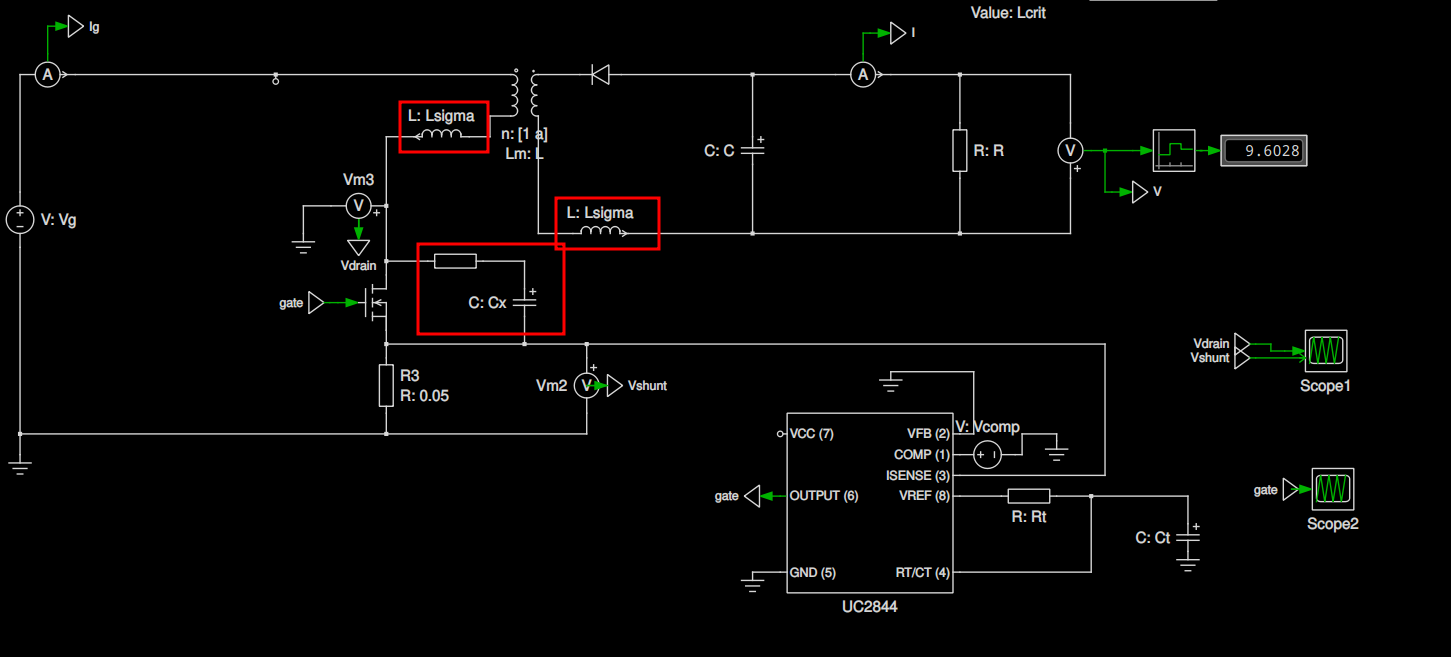
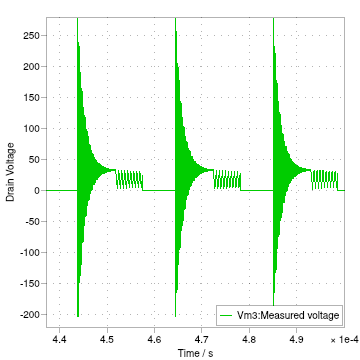

As we can see, there is significant high frequency and low frequency ringing - far above the MOSFET breakdown voltage

Next, I added the clamp as calculated in the prelab and reran the simulation

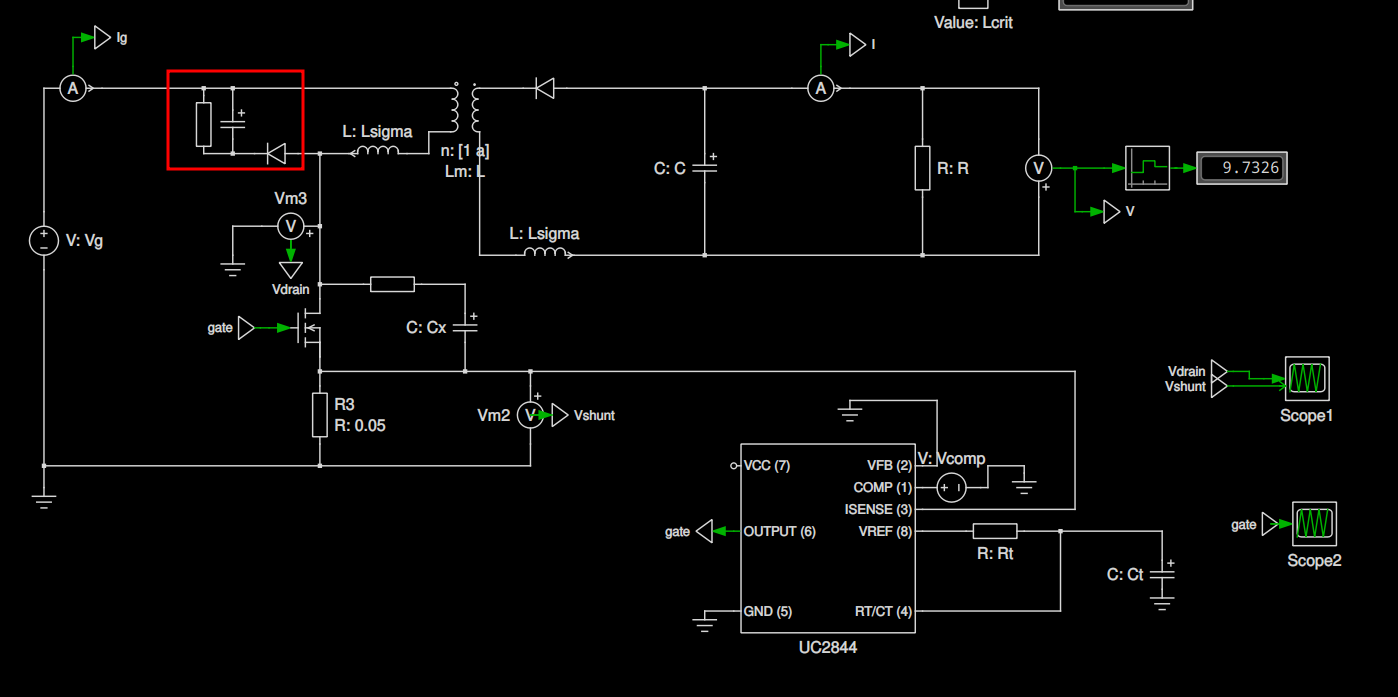
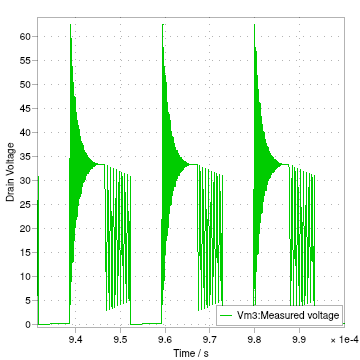

The ringing is still present, but the HF ringing is clamped at 60V, which means our clamp is functioning as intended.

Lastly, I addded the snubber. I implemented it as a single snubber capacitor connected to resistors for both the HF and LF snubber values, with the intention that the user of the sim can uncomment whichever one they wish to activate - below are plot results for HF and LF snubbers respectively.

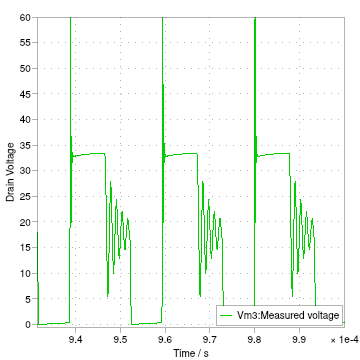

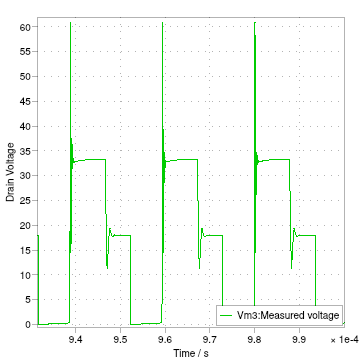

Both seem to do an adequate job at snubbing their respective ringing; the LF snubber, with its higher resistance, will snub both the high and low frequency ringing, so on our board with room for only one snubber, that one would probably make the most sense.

# Lab

Following the same procedures from Lab 6, the following code cell finds the frequency and damping ratio for the fast and slow ring in our baseline circuit (no snubber or clamp)

### Q1
Note that tht output voltage (where the Vdrain peak was 100V) was about 6.64V

### Q9

High frequency: 9_282_700 Hz | Low frequency: 1_137_398 Hz
HF Damping Ratio: 0.04019711097860463 | LF Damping Ratio: 0.013604706361964508


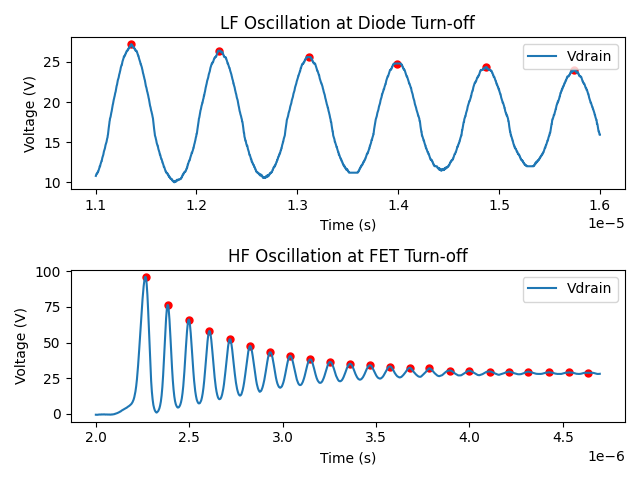

In [156]:
baseline, dt = import_and_clean('baseline', ["Vshunt", "Vdrain"], True)

hf_time = baseline[(baseline['X'] > 2e-6) & (baseline['X'] < 4.7e-6)]
lf_time = baseline[(baseline['X'] > 1.1e-5) & (baseline['X'] < 1.6e-5)]
hf_peaks, hf_f = frequency(hf_time["Vdrain"], dt, 0.8, 10)
lf_peaks, lf_f = frequency(lf_time["Vdrain"], dt, 0.8, 100)

fig, (ax1, ax2) = plt.subplots(2,1)
lf_time.plot(x='X', y='Vdrain', ax=ax1, title="LF Oscillation at Diode Turn-off")
lf_time.iloc[lf_peaks].plot(x='X', y='Vdrain', kind='scatter', ax=ax1, s=25, c='red')
hf_time.plot(x='X', y='Vdrain', ax=ax2, title="HF Oscillation at FET Turn-off")
hf_time.iloc[hf_peaks].plot(x='X', y='Vdrain', kind='scatter', ax=ax2, s=25, c='red')
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Voltage (V)")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Voltage (V)")
fig.tight_layout()
print(f'High frequency: {round(hf_f):_} Hz | Low frequency: {round(lf_f):_} Hz')
print(f'HF Damping Ratio: {damping_ratio(hf_time['Vdrain'], hf_peaks, VG + 6.64/a)} | LF Damping Ratio: {damping_ratio(lf_time['Vdrain'], lf_peaks, VG)}')


### Q10

Looking at our RLC circuit equation, we know that

$$
f_0 = \frac{1}{2\pi\sqrt{LC}}
$$

We can calculate an expected frequency using our theoretical L and C values and see if they match our actual measured frequency to verify our L and C values. The code cell below performs this calculation.


In [157]:
hf_f_theoretical = 1/(2*np.pi*np.sqrt(Cx * Lsigma_tot))
lf_f_theoretical = 1/(2*np.pi*np.sqrt(Cx * (Lsigma + Lm)))
print(f"HF: Theoretical {hf_f_theoretical:_}, Actual {hf_f:_}, Error {round(100*(hf_f_theoretical-hf_f)/hf_f, 2)}%")
print(f"LF: Theoretical {lf_f_theoretical:_}, Actual {lf_f:_}, Error {round(100*(lf_f_theoretical-lf_f)/lf_f, 2)}%")

HF: Theoretical 10_221_465.0, Actual 9_282_700.421940928, Error 10.11%
LF: Theoretical 1_574_858.2185540562, Actual 1_137_397.6342129207, Error 38.46%


Our error is about 10% for HF and 38% for LF. Given the very fuzzy nature of measuring and calculating parameters like parasitic capacitance and leakage inductances, I'd call these results good enough to prove that our theoretical L and C values are at least enough in the ballpark of the real values to be useful in designing our snubber/clamp.

### Q11

Looking at our RLC circuit equation, we know that

$$
\omega _0 = \frac{1}{\sqrt{LC}}
$$

We know that the parasitic capacitance is the same across both, and that for HF, $L = L_{\sigma \text{tot}}$ and for LF $L = L_m + L_{\sigma 1}$. Therefore, we can say

$$
\frac{\omega _{\text{hf}}}{\omega _{\text{lf}}} = \frac{\sqrt{(L_{\sigma 1} + L_m)C_x}}{\sqrt{L_{\sigma \text{tot}}C_x}}
$$

This could be used to verify experimentally that the ratio between our leakage and magentizing inductance is what we think it is. The below code cell calcualtes the ratio for our experimental data.

In [158]:
print(hf_f/lf_f)

8.161350210970465


### Q12

The following code cell determines the damped resonant frequency and damping ratio of our high frequency oscillation with our HF snubber attached. Both are calculated with the same peak-based analysis used in this lab as well as lab 6.

For the high frequency oscillation, we appear to be relatively close to a damping ratio of 0.7 - I would call it close enough to have met the goal.

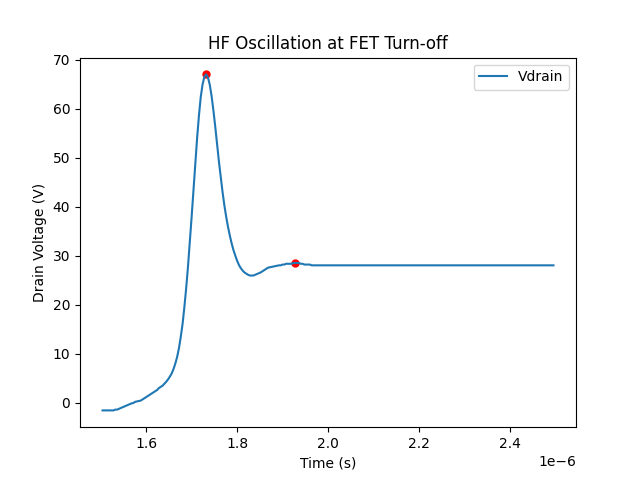

High frequency: 5_102_041 Hz | Damping Ratio: 0.6566944094072256


In [159]:
hf_snub, dt = import_and_clean('hf_snub', ["Vshunt", "Vdrain", "Cathode"], True)
hf_snub = hf_snub[(hf_snub['X'] > 1.5e-6) & (hf_snub['X'] < 2.5e-6)]
hf_snub_peaks, hf_snub_f = frequency(hf_snub["Vdrain"], dt, 0.2, 10)

plt.figure()
ax = plt.gca()
hf_snub.plot(x='X', y='Vdrain', ax=ax, title="HF Oscillation at FET Turn-off")
hf_snub.iloc[hf_snub_peaks].plot(x='X', y='Vdrain', kind='scatter', ax=ax, s=25, c='red')
ax.set_xlabel("Time (s)")
ax.set_ylabel("Drain Voltage (V)")
plt.show()

print(f'High frequency: {round(hf_snub_f):_} Hz | Damping Ratio: {damping_ratio(hf_snub['Vdrain'], hf_snub_peaks, VG + 6.5/a)}')

### Q13

The following code cell determines the damped resonant frequency and damping ratio of our low frequency oscillation with our LF snubber attached.

For the low frequency oscillation, our damping ratio only is about half of the desired ratio. This could be due to measurement error - there's really only one overshoot, so finding the peak is a little fuzzy and not precise.

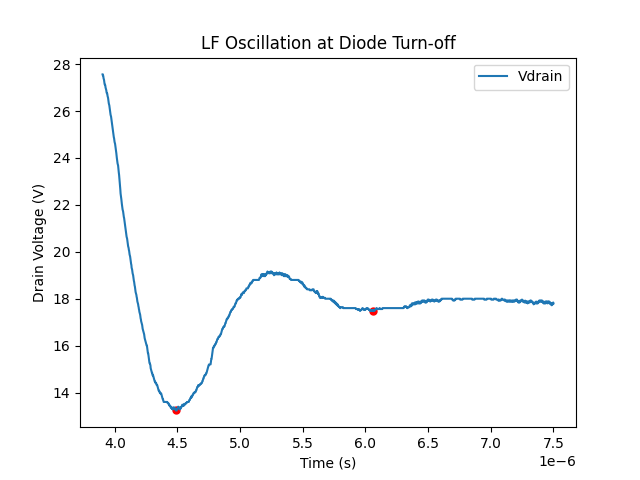

Low frequency: 636_943 Hz | Damping Ratio: 0.33236348672758714


In [160]:
lf_snub, dt = import_and_clean('lf_snub', ["Vshunt", "Vdrain"], True)
lf_snub = lf_snub[(lf_snub["X"] > 3.9e-6) & (lf_snub["X"] < 7.5e-6)]
lf_snub_peaks, lf_snub_f = frequency(-lf_snub["Vdrain"], dt, 0.5, 100)

plt.figure()
ax = plt.gca()
lf_snub.plot(x='X', y='Vdrain', ax=ax, title="LF Oscillation at Diode Turn-off")
lf_snub.iloc[lf_snub_peaks].plot(x='X', y='Vdrain', kind='scatter', ax=ax, s=25, c='red')
ax.set_xlabel("Time (s)")
ax.set_ylabel("Drain Voltage (V)")
plt.show()

print(f'Low frequency: {round(lf_snub_f):_} Hz | Damping Ratio: {abs(damping_ratio(lf_snub['Vdrain'], lf_snub_peaks, VG))}')

### Q14

A. To find the voltage of C16, we take it's positive end (the cathode measurement) and subtract the negative end from it (the input voltage). The code cell below plots this for both a 10V output and the 6.64V output.

Text(0, 0.5, 'Voltage (V)')

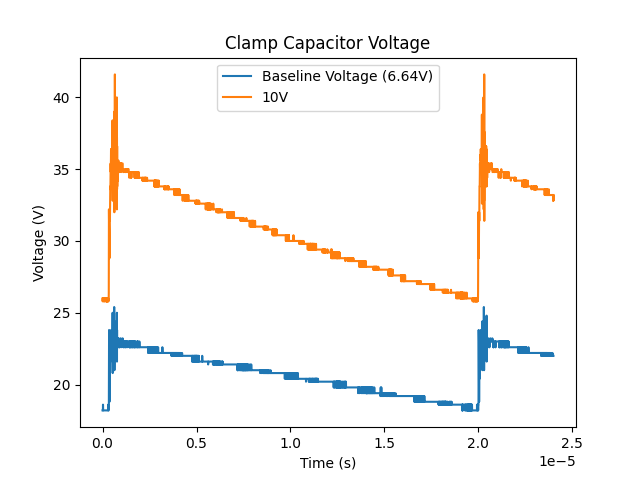

In [161]:
clamp_vobl, dt = import_and_clean("clamp_bl", ["Vshunt", "Vdrain", "Vcathode"], False)
clamp_10, _ = import_and_clean("clamp_10", ["Vshunt", "Vdrain", "Vcathode"], False)
dfs = [clamp_vobl, clamp_10]
names = ["Baseline Voltage", "10V"]
Vos = [6.64, 10]

plt.figure()
ax = plt.gca()
for df in [clamp_vobl, clamp_10]:
    c16 = df["Vcathode"] - VG
    plt.plot(df['X'], c16)
ax.legend(["Baseline Voltage (6.64V)", "10V"])
ax.set_title("Clamp Capacitor Voltage")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (V)")


B. We can find when the diode is on by finding when it has a lower potential than the drain voltage, so the energy stored in the leakage inductance would flow through it. In electrical terms, when the drain voltage is higher than the forward voltage of the diode (1.07V per its datasheet) plus the voltage over the capacitor plus the supply voltage.

In graphical terms below, the diode is on when the blue line exceeds the orange line (for 10V output). 

(0.0, 3.5e-06)

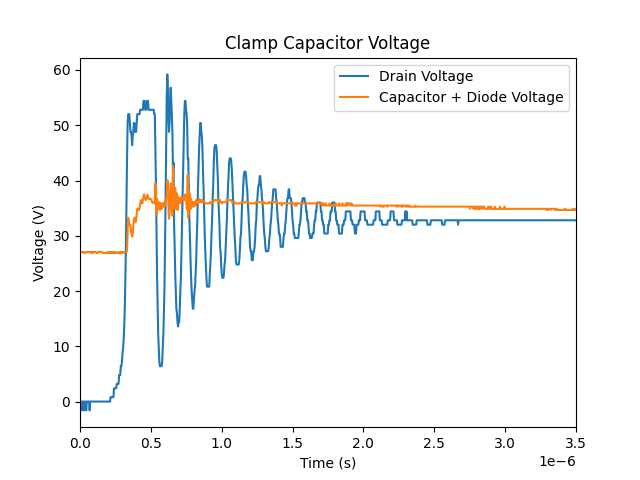

In [162]:
plt.figure()
ax = plt.gca()
for df in [clamp_10]:
    Vccp = df['Vcathode'] - VG
    plt.plot(df['X'], df["Vdrain"])
    plt.plot(df['X'], Vccp + 1.07)

ax.legend(["Drain Voltage", "Capacitor + Diode Voltage"])
ax.set_title("Clamp Capacitor Voltage")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (V)")
ax.set_xlim([0, 3.5e-6])

C. The below code cell calculates finds the peak and ripple of the C16 Voltage at a 10V output. The peak is simply the max voltage, while the ripple is the distance of this max voltage from our average clamp voltage, which through manual inspection of this graph seems to be about 35V.

In [163]:
Vccp = clamp_10['Vcathode'] - VG
Vcp_actual = 35
pk = max(Vccp)
print(f"Peak capacitor voltage at 10V output: {pk}")
print(f"Capacitor Ripple 10V output: {round(100 * (pk - Vcp_actual)/Vcp_actual, 2)}%")


Peak capacitor voltage at 10V output: 41.6
Capacitor Ripple 10V output: 18.86%


D. Average power

We can use the same equation we used to select our resistor to find our average power by solving it for power, and then plugging in our actual selected resistor of 1.5 $\text{k}\Omega$ and clamp voltage of about 35V.

$$
R_{cp} = \frac{V_{cp}^2}{<P_{cp}>}
$$

That calculation is in the code cell below.

In [164]:
Rcp = 1500
Pcp_avg = Vcp_actual**2 / Rcp
print(f"Average power dissipated by clamp: {round(Pcp_avg, 3)} W")

Average power dissipated by clamp: 0.817 W


E. Finding Clamp Capacitance

The below code cell finds the output capacitance by fitting an exponential curve to the discharge portion of the Ccp voltage graph

In [165]:
c_time = clamp_10[(clamp_10['X'] > 1.3e-6) * (clamp_10['X'] < 1.9e-5)]
Vccp = c_time['Vcathode'] - VG


def exp_func(x, a, b):
    return a * np.exp(b*x)

popt, pcov = curve_fit(exp_func, c_time["X"], Vccp, p0=(1, -0.1))
print('Python Fit Parameters:', popt)

Python Fit Parameters: [    35.5304778  -16176.07987521]


In [166]:
tau = 1/16176.07987521
C = tau/Rcp
print(f"Capacitance is {C} F")

Capacitance is 4.121311663948568e-08 F


F. Comparison with PLECS sim

By attaching a voltmeter to the clamp capacitor, I was able to generate this plot, which is the equivalent of the orange line from the plot in part A (bottom plot). Both snubbers were also commented out here.

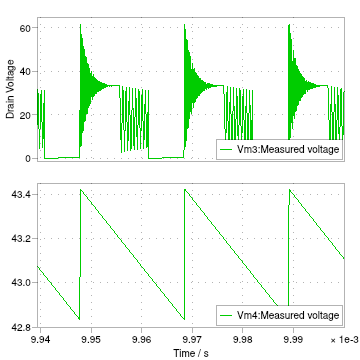

Shape wise, the two plots are similar; the capacitor charges when the FET turns off, then discharges over the remainder of the cycle until the FET turns off again. Interestingly, however, the amplitude is lower in our real measurement - peaking at about 35V as opposed to 44V - and the range of capacitor voltages is also much higher - nearly a 10V difference in our real measurement as opposed to just 3V in the sim. One element that we are not including in the sim is any of our wire or winding resistance; it's possible that this may be the cause of the inconsistency, however I am not very confident in this.